## Install Libraries

In [1]:
!pip install langgraph langchain_openai openai langchain_community tavily-python duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: openai
    Found existing installation: openai 2.43.0
    Uninstalling openai-2.43.0:
      Successfully uninstalled openai-2.43.0
  Attempting uninstall: langchain-core
    Found existing 

## Load Libraries

In [2]:
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [3]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

from langchain_community.tools import DuckDuckGoSearchRun

/tmp/ipykernel_1530/2591366162.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


## Configure Agent

In [4]:
# Define a TypedDict for the state, with a list of messages annotated with 'add_messages'
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Initialize a StateGraph with the defined state type
graph_builder = StateGraph(State)

# Define a tool that uses DuckDuckGo to search the web
@tool
def DuckDuckGoSearch(query: str) -> str:
    """Use DuckDuckGo to search the web."""
    search = DuckDuckGoSearchRun()  # Create a DuckDuckGo search runner
    return search.invoke(query)  # Perform the search and return the result

# Define a tool to request human assistance for tool selection
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human regarding which tool to select."""
    human_response = interrupt({"query": query})  # Send an interrupt with the query
    return human_response["data"]  # Return the human's response data

# Initialize a Tavily search tool with a maximum of 2 results
tavily_tool = TavilySearchResults(max_results=2)

# Define a list of tools available to the chatbot
tools = [tavily_tool, DuckDuckGoSearch, human_assistance]

# Create an instance of the language model with a specific configuration
llm = ChatOpenAI(model="gpt-4o-mini")

# Bind the tools to the language model
llm_with_tools = llm.bind_tools(tools)

# Define the chatbot function that processes messages using the language model and tools
def chatbot(state: State):
    # Invoke the language model with the current state messages
    message = llm_with_tools.invoke(state["messages"])
    # Ensure the model makes at most one tool call
    assert(len(message.tool_calls) <= 1)
    # Return the updated state with the new message
    return {"messages": [message]}

# Add the chatbot function as a node in the state graph
graph_builder.add_node("chatbot", chatbot)

# Create a ToolNode with the list of tools and add it to the graph
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Add conditional edges from the chatbot node based on tool conditions
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # Define the conditions for tool execution
)

# Add a direct edge from the tools node to the chatbot node
graph_builder.add_edge("tools", "chatbot")

# Add a starting edge to the chatbot node
graph_builder.add_edge(START, "chatbot")

# Initialize a memory saver for the graph's checkpoints
memory = MemorySaver()

# Compile the state graph with the memory saver as the checkpointer
graph = graph_builder.compile(checkpointer=memory)

/tmp/ipykernel_1530/228334325.py:23: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=2)


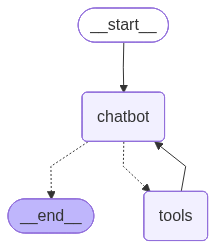

In [5]:
# Display graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Test Human in Loop

In [6]:
# Define user input for the agent
user_input = "When is the India vs England 1st T20i happening in 2025?"

# Configuration settings for the graph -> thread id
config = {"configurable": {"thread_id": "User_1"}}

# Stream events through the graph with the provided input and configuration
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},  # Initial user message
    config,  # Configuration details
    stream_mode="values",
)

# Iterate through the streamed events
for event in events:
    # Check if the event contains messages
    if "messages" in event:
        # Pretty-print the last message in the list of messages
        event["messages"][-1].pretty_print()

================================ Human Message =================================

When is the India vs England 1st T20i happening in 2025?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_htQ3c03jpC7otxXXDj430NXi)
 Call ID: call_htQ3c03jpC7otxXXDj430NXi
  Args:
    query: India vs England 1st T20i 2025 date
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "India vs England 2025 Cricket Schedule, Upcoming Cricket Matches – NDTV Sports", "url": "https://sports.ndtv.com/india-vs-england-2025/schedules-fixtures", "content": "Don't Miss\n\nBundesliga Blueprint: How Zee Plans To Complete India's Football Jigsaw\n\nManuel Neuer Doesn't Know Where To Stop: Not On The Pitch, Not In His Career\n\n\"Won't Let my Kid Play Badminton\": Thomas Cup Heroes Flag Lack of Support\n\nWhy A Sooryavanshi Question To Manu Bhaker Has Created A Social Media

So for this question the model thought of calling the Tavily search without asking the human for help. Lets look at another example.

In [7]:
user_input = "I need help with creating code for configuring OpenAI keys?"
config = {"configurable": {"thread_id": "User_1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need help with creating code for configuring OpenAI keys?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_JqhHtgZX6LQhsNZdqVwX7jz4)
 Call ID: call_JqhHtgZX6LQhsNZdqVwX7jz4
  Args:
    query: how to create code for configuring OpenAI API keys in a project
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_JqhHtgZX6LQhsNZdqVwX7jz4)
 Call ID: call_JqhHtgZX6LQhsNZdqVwX7jz4
  Args:
    query: how to create code for configuring OpenAI API keys in a project


In [8]:
# see where the graph is currently pointing at
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [9]:
human_response = (
    "Call Tavily"
)

human_command = Command(resume={"data": human_response}) # Send human response via Command function

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_JqhHtgZX6LQhsNZdqVwX7jz4)
 Call ID: call_JqhHtgZX6LQhsNZdqVwX7jz4
  Args:
    query: how to create code for configuring OpenAI API keys in a project
================================= Tool Message =================================
Name: human_assistance

Call Tavily
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_Ew89pXTljOSWdCdcFSzzoQM3)
 Call ID: call_Ew89pXTljOSWdCdcFSzzoQM3
  Args:
    query: OpenAI API key configuration code example
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "How to config OpenAI API on my Control", "url": "https://learn.microsoft.com/en-us/answers/questions/5568574/how-to-config-openai-api-on-my-control", "content": "1. Create an OpenAI Account and Get API Key:\n       Go to OpenAI Platfo

So here we told model to use which tool, similarly could pass more details with the human message as well.